# Loading and visualizing data from flat files
## Exercise 2
### Part 1


In [6]:
import pandas as pd
df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None)
df.columns = ["Date", "Time", "Depth(m)", "Temperature", "Salinity(psu)"]
df.to_csv("ctd_profile_time.dat .csv", sep=",", index=False)
print (df.head())

         Date   Time  Depth(m)  Temperature  Salinity(psu)
0  11/29/2008  06:52         5        28.97          35.21
1  11/29/2008  06:52         6        28.98          35.21
2  11/29/2008  06:52         7        28.99          35.21
3  11/29/2008  06:52         8        28.96          35.21
4  11/29/2008  06:52         9        28.99          35.21


## Part 2

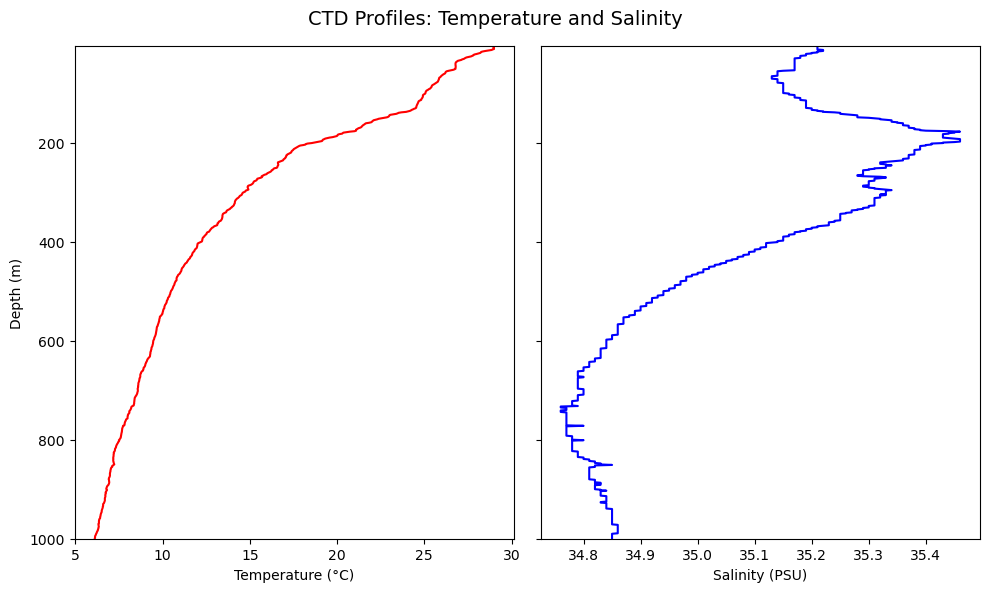

In [11]:
import matplotlib.pyplot as plt
depth = df["Depth(m)"]
temperature = df["Temperature"]
salinity = df["Salinity(psu)"]
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
# Temperature profile
axes[0].plot(temperature, depth, color="red", linestyle="-")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_ylim(depth.max(), depth.min())


# Salinity profile
axes[1].plot(salinity, depth, color="blue", linestyle="-")
axes[1].set_xlabel("Salinity (PSU)")
axes[1].set_ylim(depth.max(), depth.min())
# Title for the whole figure
fig.suptitle("CTD Profiles: Temperature and Salinity", fontsize=14)

plt.tight_layout()
plt.show()

## Part 3

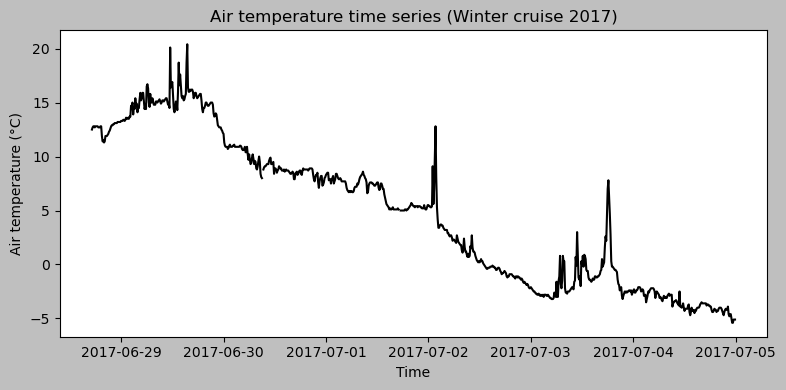

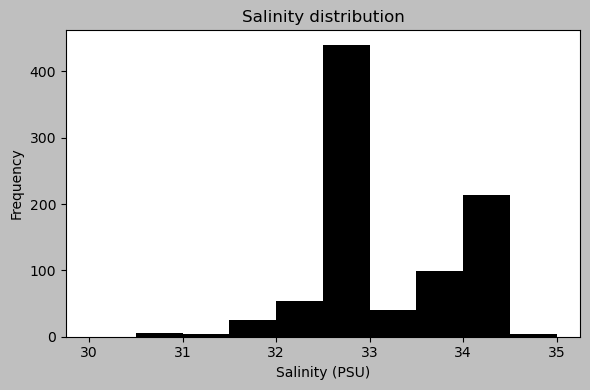

                           Mean       Std        IQR
Air temperature (°C)   4.878271  6.692847  11.675000
Salinity (PSU)        33.110553  1.140150   1.272575


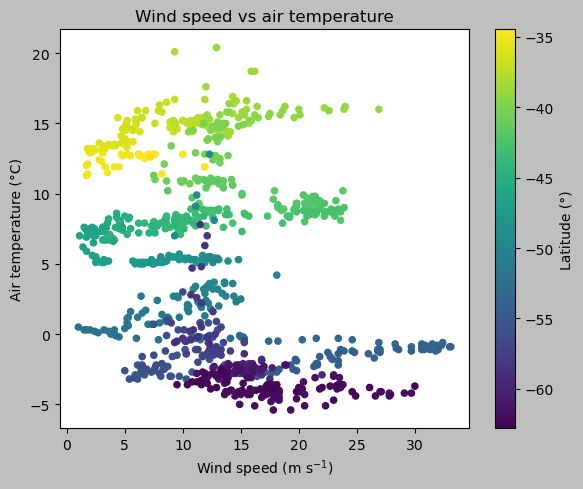

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Load CSV, parse time index, handle missing values
# -------------------------------------------------------

file_path = "SAA2_WC_2017_metocean_10min_avg.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["TIME_SERVER"],
    na_values=["NULL"]
)

# Set time as index
df = df.set_index("TIME_SERVER")

# Select data from departure up to and including July 4th, 2017
df_sel = df.loc[: "2017-07-04"]

# -------------------------------------------------------
# 2. Time series of air temperature (grayscale)
# -------------------------------------------------------

plt.style.use("grayscale")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    df_sel.index,
    df_sel["AIR_TEMPERATURE"],
    linewidth=1.5
)

ax.set_xlabel("Time")
ax.set_ylabel("Air temperature (°C)")
ax.set_title("Air temperature time series (Winter cruise 2017)")

plt.tight_layout()
plt.savefig("air_temperature_timeseries.png", dpi=300)
plt.show()

# -------------------------------------------------------
# 3. Histogram of salinity (bins = 0.5 psu, 30–35)
# -------------------------------------------------------

sal = df_sel["TSG_SALINITY"].dropna()

bins = np.arange(30, 35.5, 0.5)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sal, bins=bins)

ax.set_xlabel("Salinity (PSU)")
ax.set_ylabel("Frequency")
ax.set_title("Salinity distribution")

plt.tight_layout()
plt.savefig("salinity_histogram.png", dpi=300)
plt.show()

# -------------------------------------------------------
# 4. Mean, standard deviation, IQR (table)
# -------------------------------------------------------

def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

stats_table = pd.DataFrame(
    {
        "Mean": [
            df_sel["AIR_TEMPERATURE"].mean(),
            df_sel["TSG_SALINITY"].mean()
        ],
        "Std": [
            df_sel["AIR_TEMPERATURE"].std(),
            df_sel["TSG_SALINITY"].std()
        ],
        "IQR": [
            iqr(df_sel["AIR_TEMPERATURE"]),
            iqr(df_sel["TSG_SALINITY"])
        ]
    },
    index=["Air temperature (°C)", "Salinity (PSU)"]
)

print(stats_table)

# -------------------------------------------------------
# 5. Scatter plot: wind speed vs air temperature
#    Latitude encoded by colour (300 DPI PNG)
# -------------------------------------------------------

# Convert latitude from ddmm.mmmm (S) to decimal degrees
def ddmm2dd(ddmm):
    thedeg = np.floor(ddmm / 100.)
    themin = (ddmm - thedeg * 100.) / 60.
    return thedeg + themin

lat_dd = -ddmm2dd(df_sel["LATITUDE"])

scatter_df = df_sel[
    ["WIND_SPEED_REL", "AIR_TEMPERATURE"]
].copy()

scatter_df["LAT_DEG"] = lat_dd
scatter_df = scatter_df.dropna()

fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    scatter_df["WIND_SPEED_REL"],
    scatter_df["AIR_TEMPERATURE"],
    c=scatter_df["LAT_DEG"],
    cmap="viridis",
    s=20
)

ax.set_xlabel("Wind speed (m s$^{-1}$)")
ax.set_ylabel("Air temperature (°C)")
ax.set_title("Wind speed vs air temperature")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.savefig("wind_vs_temperature_latitude.png", dpi=300)
plt.show()
